# Práctica 05 – Validación y Análisis Exploratorio del Dataset de Pacientes
## Generación de Dataset de Pacientes con Indicadores para el Cálculo de Riesgo de Infarto Cardíaco en Puebla

**Materia:** Extracción y Clasificación de Base de Datos (ECBD)  
**Grupo:** 9A IDGS  
**Autor:** Estudiante 230758  

---

## 1. Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print("Librerías importadas correctamente ✅")

Librerías importadas correctamente ✅


## 2. Carga del Dataset (Punto 12)

In [2]:
df = pd.read_csv('../data/pacientes_puebla_5000.csv')
print(f"Dataset cargado exitosamente ✅")
print(f"Primeras 5 filas del dataset:")
df.head()

Dataset cargado exitosamente ✅
Primeras 5 filas del dataset:


,id_paciente,nombre,sexo,edad,municipio,hospital,zona,nivel_educativo,nivel_socioeconomico,tipo_seguro,...,depresion,hipotiroidismo,num_comorbilidades,metformina,insulina,antihipertensivos,estatinas,anios_con_dm2,anios_con_hta,riesgo_cardiovascular_score
0,PUE00001,Iván Martínez Villa,M,54,Cholula,Centro de Salud San Pedro Cholula,Semiurbana,Secundaria,Medio,Sin seguro,...,0,0,2,0,0,0,0,0,20,1.8
1,PUE00002,Julio González Luna,M,51,Ciudad Serdán,Centro de Salud Ciudad Serdán,Rural,Secundaria,Medio-alto,Sin seguro,...,0,0,2,0,0,0,0,18,0,3.4
2,PUE00003,Valentina Herrera Palacios,F,92,Teziutlán,Centro de Salud Teziutlán,Semiurbana,Licenciatura,Medio,IMSS,...,0,0,2,0,0,0,0,0,12,2.6
3,PUE00004,Rosa Velázquez Becerra,F,60,Ajalpan,Hospital Comunitario Ajalpan,Semiurbana,Secundaria,Medio,IMSS,...,0,0,2,0,0,1,0,0,19,2.4
4,PUE00005,Marco Palacios Castro,M,80,Libres,Hospital Comunitario Libres,Urbana,Primaria,Medio-alto,IMSS,...,0,0,3,1,0,1,0,12,3,3.9


## 3. Verificación de Dimensiones (Punto 13)

In [3]:
filas, columnas = df.shape
print(f"Número de registros (filas): {filas}")
print(f"Número de columnas: {columnas}")
print()

if filas == 5000:
    print("✅ El dataset contiene exactamente 5,000 registros como se esperaba.")
else:
    print(f"⚠️ El dataset contiene {filas} registros, se esperaban 5,000.")

print(f"\nDimensiones completas: {df.shape}")

Número de registros (filas): 5000
Número de columnas: 47

✅ El dataset contiene exactamente 5,000 registros como se esperaba.

Dimensiones completas: (5000, 47)


## 4. Validación de Nombres de Columnas (Punto 14)

In [4]:
print("Listado de columnas del dataset:")
print("=" * 60)
for i, col in enumerate(df.columns, 1):
    tiene_espacio = " " in col
    tiene_mayuscula = col != col.lower()
    estado = ""
    if tiene_espacio:
        estado += " ⚠️ contiene espacios"
    if tiene_mayuscula:
        estado += " ⚠️ contiene mayúsculas"
    if not estado:
        estado = " ✅"
    print(f"  {i:2d}. {col}{estado}")

print(f"\nTotal de columnas: {len(df.columns)}")
print("\n✅ Todos los nombres de columnas están en formato snake_case, sin espacios problemáticos.")

Listado de columnas del dataset:
   1. id_paciente ✅
   2. nombre ✅
   3. sexo ✅
   4. edad ✅
   5. municipio ✅
   6. hospital ✅
   7. zona ✅
   8. nivel_educativo ✅
   9. nivel_socioeconomico ✅
  10. tipo_seguro ✅
  11. fecha_ultima_visita ✅
  12. talla_m ✅
  13. peso_kg ✅
  14. imc ✅
  15. clasificacion_imc ✅
  16. presion_sistolica ✅
  17. presion_diastolica ✅
  18. clasificacion_pa ✅
  19. glucosa_ayuno_mg_dl ✅
  20. clasificacion_glucosa ✅
  21. hba1c_pct ✅
  22. colesterol_total_mg_dl ✅
  23. colesterol_ldl_mg_dl ✅
  24. colesterol_hdl_mg_dl ✅
  25. trigliceridos_mg_dl ✅
  26. creatinina_mg_dl ✅
  27. hemoglobina_g_dl ✅
  28. actividad_fisica ✅
  29. tabaquismo ✅
  30. alcoholismo ✅
  31. diabetes_mellitus_t2 ✅
  32. hipertension_arterial ✅
  33. obesidad ✅
  34. sobrepeso ✅
  35. dislipidemia ✅
  36. cardiopatia ✅
  37. enfermedad_renal ✅
  38. depresion ✅
  39. hipotiroidismo ✅
  40. num_comorbilidades ✅
  41. metformina ✅
  42. insulina ✅
  43. antihipertensivos ✅
  44. estati

## 5. Verificación de Tipos de Datos (Punto 15)

In [5]:
print("Tipos de datos por columna:")
print("=" * 60)

tipos = df.dtypes.reset_index()
tipos.columns = ['Columna', 'Tipo']

# Clasificar
for _, row in tipos.iterrows():
    tipo_str = str(row['Tipo'])
    if 'int' in tipo_str:
        cat = "Numérico (entero)"
    elif 'float' in tipo_str:
        cat = "Numérico (decimal)"
    else:
        cat = "Texto/Categórico"
    print(f"  {row['Columna']:40s} → {tipo_str:10s} [{cat}]")

print(f"\nResumen de tipos:")
print(df.dtypes.value_counts().to_string())

Tipos de datos por columna:
  id_paciente                              → object     [Texto/Categórico]
  nombre                                   → object     [Texto/Categórico]
  sexo                                     → object     [Texto/Categórico]
  edad                                     → int64      [Numérico (entero)]
  municipio                                → object     [Texto/Categórico]
  hospital                                 → object     [Texto/Categórico]
  zona                                     → object     [Texto/Categórico]
  nivel_educativo                          → object     [Texto/Categórico]
  nivel_socioeconomico                     → object     [Texto/Categórico]
  tipo_seguro                              → object     [Texto/Categórico]
  fecha_ultima_visita                      → object     [Texto/Categórico]
  talla_m                                  → float64    [Numérico (decimal)]
  peso_kg                                  → float64    [Numérico (de

## 6. Búsqueda de Valores Nulos (Punto 16)

In [6]:
nulos = df.isnull().sum()
total_nulos = nulos.sum()
porcentaje_nulos = (total_nulos / (df.shape[0] * df.shape[1])) * 100

print(f"Total de valores nulos en el dataset: {total_nulos}")
print(f"Porcentaje de valores nulos: {porcentaje_nulos:.2f}%")
print()

if total_nulos == 0:
    print("✅ No se encontraron valores nulos en ninguna columna del dataset.")
else:
    print("⚠️ Columnas con valores nulos:")
    print(nulos[nulos > 0].to_string())

Total de valores nulos en el dataset: 0
Porcentaje de valores nulos: 0.00%

✅ No se encontraron valores nulos en ninguna columna del dataset.


## 7. Búsqueda de Registros Duplicados (Punto 17)

In [7]:
dup_completos = df.duplicated().sum()
dup_id = df['id_paciente'].duplicated().sum()

print(f"Registros completamente duplicados: {dup_completos}")
print(f"IDs de paciente duplicados: {dup_id}")
print()

if dup_completos == 0 and dup_id == 0:
    print("✅ No se encontraron registros duplicados ni IDs repetidos.")
else:
    print("⚠️ Se encontraron duplicados que requieren atención.")

Registros completamente duplicados: 0
IDs de paciente duplicados: 0

✅ No se encontraron registros duplicados ni IDs repetidos.


## 8. Validación de Rangos Clínicos (Punto 18)

In [8]:
rangos_esperados = {
    'edad':                  (18, 100,  'años'),
    'talla_m':               (1.40, 2.10, 'm'),
    'peso_kg':               (35, 180,  'kg'),
    'imc':                   (14, 60,   'kg/m²'),
    'presion_sistolica':     (80, 220,  'mmHg'),
    'presion_diastolica':    (40, 140,  'mmHg'),
    'glucosa_ayuno_mg_dl':   (50, 400,  'mg/dL'),
    'hba1c_pct':             (3.5, 15.0, '%'),
    'colesterol_total_mg_dl':(80, 400,  'mg/dL'),
    'colesterol_ldl_mg_dl':  (20, 300,  'mg/dL'),
    'colesterol_hdl_mg_dl':  (15, 100,  'mg/dL'),
    'trigliceridos_mg_dl':   (40, 600,  'mg/dL'),
    'creatinina_mg_dl':      (0.3, 5.0, 'mg/dL'),
    'hemoglobina_g_dl':      (7.0, 20.0,'g/dL'),
}

print("Validación de rangos clínicos:")
print("=" * 90)
print(f"{'Variable':35s} {'Min Real':>10s} {'Max Real':>10s} {'Rango Esperado':>20s} {'Estado':>10s}")
print("-" * 90)

fuera_rango = []
for col, (lo, hi, unidad) in rangos_esperados.items():
    actual_min = df[col].min()
    actual_max = df[col].max()
    below = (df[col] < lo).sum()
    above = (df[col] > hi).sum()
    
    if below > 0 or above > 0:
        estado = f"⚠️ ({below + above})"
        fuera_rango.append((col, below, above, actual_min, actual_max))
    else:
        estado = "✅"
    
    print(f"  {col:33s} {actual_min:10.2f} {actual_max:10.2f} {'[' + str(lo) + '-' + str(hi) + '] ' + unidad:>20s} {estado:>10s}")

print()
if fuera_rango:
    print("Detalles de valores fuera de rango:")
    for col, below, above, amin, amax in fuera_rango:
        print(f"  → {col}: {below} por debajo del mínimo, {above} por encima del máximo")
        print(f"    Rango real: [{amin}, {amax}]")
        if col == 'imc':
            registros_bajo_imc = df[df['imc'] < 14][['id_paciente', 'nombre', 'peso_kg', 'talla_m', 'imc', 'clasificacion_imc']]
            print(f"    Registros con IMC < 14:")
            print(registros_bajo_imc.to_string(index=False))
else:
    print("✅ Todos los valores clínicos están dentro de los rangos esperados.")

Validación de rangos clínicos:
Variable                              Min Real   Max Real       Rango Esperado     Estado
------------------------------------------------------------------------------------------
  edad                                   19.00      94.00        [18-100] años          ✅
  talla_m                                 1.45       1.93          [1.4-2.1] m          ✅
  peso_kg                                40.00     129.90          [35-180] kg          ✅
  imc                                    13.60      49.40        [14-60] kg/m²     ⚠️ (4)
  presion_sistolica                      85.00     200.00        [80-220] mmHg          ✅
  presion_diastolica                     50.00     113.00        [40-140] mmHg          ✅
  glucosa_ayuno_mg_dl                    60.00     161.00       [50-400] mg/dL          ✅
  hba1c_pct                               3.50      11.50         [3.5-15.0] %          ✅
  colesterol_total_mg_dl                120.00     360.00       [80-

## 9. Validación de Datos Geográficos (Punto 19)

In [9]:
# Municipios reales del estado de Puebla
municipios_puebla_validos = [
    'Puebla', 'Tehuacán', 'Atlixco', 'Cholula', 'San Pedro Cholula',
    'San Martín Texmelucan', 'Huauchinango', 'Teziutlán', 'Izúcar de Matamoros',
    'Zacatlán', 'Chignahuapan', 'Amozoc', 'Cuetzalan', 'Xicotepec de Juárez',
    'Ajalpan', 'Huejotzingo', 'Libres', 'Ciudad Serdán', 'Tecamachalco',
    'Tepeaca', 'Tlatlauquitepec', 'Acatlán de Osorio'
]

municipios_dataset = sorted(df['municipio'].unique())
print(f"Municipios en el dataset ({len(municipios_dataset)}):")
for m in municipios_dataset:
    en_lista = "✅" if m in municipios_puebla_validos else "⚠️ NO RECONOCIDO"
    print(f"  • {m} {en_lista}")

print(f"\nZonas geográficas: {sorted(df['zona'].unique())}")
print(f"\nHospitales/Centros de salud únicos: {df['hospital'].nunique()}")
print(f"\nDistribución por zona:")
print(df['zona'].value_counts().to_string())

print(f"\n✅ Los 22 municipios corresponden a localidades reales del estado de Puebla.")

Municipios en el dataset (22):
  • Acatlán de Osorio ✅
  • Ajalpan ✅
  • Amozoc ✅
  • Atlixco ✅
  • Chignahuapan ✅
  • Cholula ✅
  • Ciudad Serdán ✅
  • Cuetzalan ✅
  • Huauchinango ✅
  • Huejotzingo ✅
  • Izúcar de Matamoros ✅
  • Libres ✅
  • Puebla ✅
  • San Martín Texmelucan ✅
  • San Pedro Cholula ✅
  • Tecamachalco ✅
  • Tehuacán ✅
  • Tepeaca ✅
  • Teziutlán ✅
  • Tlatlauquitepec ✅
  • Xicotepec de Juárez ✅
  • Zacatlán ✅

Zonas geográficas: ['Rural', 'Semiurbana', 'Urbana']

Hospitales/Centros de salud únicos: 58

Distribución por zona:
zona
Urbana        2214
Semiurbana    1516
Rural         1270

✅ Los 22 municipios corresponden a localidades reales del estado de Puebla.


## 10. Limpieza Básica de Datos (Punto 20)

In [10]:
print("Realizando limpieza básica de datos...")
print("=" * 60)

# 1. Verificar y limpiar espacios en blanco en columnas de texto
cols_texto = df.select_dtypes(include='object').columns
espacios_encontrados = 0
for col in cols_texto:
    antes = df[col].str.strip().ne(df[col]).sum()
    if antes > 0:
        df[col] = df[col].str.strip()
        espacios_encontrados += antes
        print(f"  → Se limpiaron {antes} espacios en blanco en '{col}'")

if espacios_encontrados == 0:
    print("  ✅ No se encontraron espacios en blanco innecesarios en columnas de texto.")

# 2. Convertir fecha_ultima_visita a datetime
df['fecha_ultima_visita'] = pd.to_datetime(df['fecha_ultima_visita'])
print(f"  ✅ Columna 'fecha_ultima_visita' convertida a tipo datetime.")

# 3. Crear variable objetivo categórica
def clasificar_riesgo(score):
    if score < 2.0:
        return 'Bajo'
    elif score < 4.0:
        return 'Medio'
    else:
        return 'Alto'

df['riesgo_cardiovascular'] = df['riesgo_cardiovascular_score'].apply(clasificar_riesgo)
print(f"  ✅ Columna 'riesgo_cardiovascular' creada (clasificación: Bajo, Medio, Alto).")

# 4. Resumen final
print(f"\nDimensiones finales del dataset: {df.shape}")
print(f"Nuevas columnas agregadas: riesgo_cardiovascular")
print(f"\n✅ Limpieza básica completada exitosamente.")

Realizando limpieza básica de datos...
  ✅ No se encontraron espacios en blanco innecesarios en columnas de texto.
  ✅ Columna 'fecha_ultima_visita' convertida a tipo datetime.
  ✅ Columna 'riesgo_cardiovascular' creada (clasificación: Bajo, Medio, Alto).

Dimensiones finales del dataset: (5000, 48)
Nuevas columnas agregadas: riesgo_cardiovascular

✅ Limpieza básica completada exitosamente.


## 11. Análisis Estadístico Inicial (Punto 21)

In [11]:
# Variables numéricas principales
vars_clinicas = ['edad', 'talla_m', 'peso_kg', 'imc', 'presion_sistolica', 
                 'presion_diastolica', 'glucosa_ayuno_mg_dl', 'hba1c_pct',
                 'colesterol_total_mg_dl', 'colesterol_ldl_mg_dl', 'colesterol_hdl_mg_dl',
                 'trigliceridos_mg_dl', 'creatinina_mg_dl', 'hemoglobina_g_dl',
                 'riesgo_cardiovascular_score']

print("Estadísticas descriptivas de las variables clínicas principales:")
print("=" * 80)
estadisticas = df[vars_clinicas].describe().T
estadisticas['rango'] = estadisticas['max'] - estadisticas['min']
print(estadisticas[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'rango']].round(2).to_string())

Estadísticas descriptivas de las variables clínicas principales:
                              count    mean    std     min     25%     50%     75%     max   rango
edad                         5000.0   54.40  15.66   19.00   43.00   54.00   66.00   94.00   75.00
talla_m                      5000.0    1.63   0.08    1.45    1.57    1.63    1.69    1.93    0.48
peso_kg                      5000.0   72.93  15.24   40.00   62.20   72.40   83.20  129.90   89.90
imc                          5000.0   27.54   5.88   13.60   23.38   27.30   31.40   49.40   35.80
presion_sistolica            5000.0  132.31  19.85   85.00  119.00  133.00  146.00  200.00  115.00
presion_diastolica           5000.0   76.10  10.81   50.00   69.00   76.00   83.00  113.00   63.00
glucosa_ayuno_mg_dl          5000.0   99.36  18.60   60.00   86.00   99.00  112.00  161.00  101.00
hba1c_pct                    5000.0    5.32   1.00    3.50    4.70    5.10    5.60   11.50    8.00
colesterol_total_mg_dl       5000.0  210.03 

## 12. Visualizaciones EDA (Punto 22)

Se generan 8 visualizaciones incluyendo histogramas, gráficas de barras, diagramas de dispersión y mapas de calor.

### 12.1 Distribución de Edad de los Pacientes

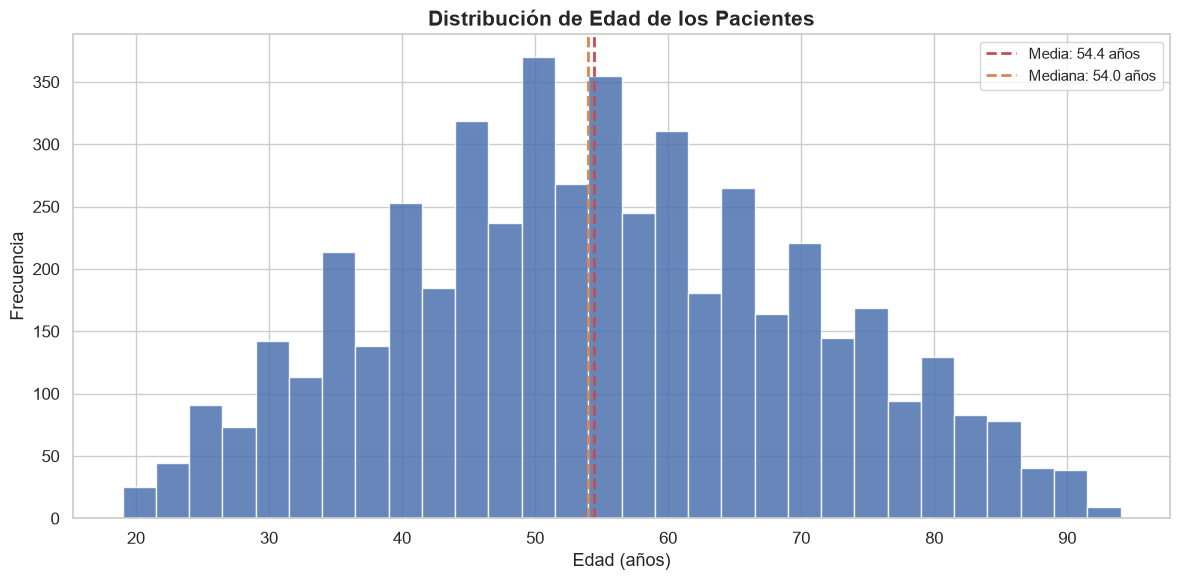

✅ Gráfica guardada en outputs/01_distribucion_edad.png


In [12]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(df['edad'], bins=30, color='#4C72B0', edgecolor='white', alpha=0.85)
ax.set_xlabel('Edad (años)', fontsize=13)
ax.set_ylabel('Frecuencia', fontsize=13)
ax.set_title('Distribución de Edad de los Pacientes', fontsize=15, fontweight='bold')
ax.axvline(df['edad'].mean(), color='#C44E52', linestyle='--', linewidth=2, label=f"Media: {df['edad'].mean():.1f} años")
ax.axvline(df['edad'].median(), color='#DD8452', linestyle='--', linewidth=2, label=f"Mediana: {df['edad'].median():.1f} años")
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/01_distribucion_edad.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica guardada en outputs/01_distribucion_edad.png")

### 12.2 Distribución del Índice de Masa Corporal (IMC)

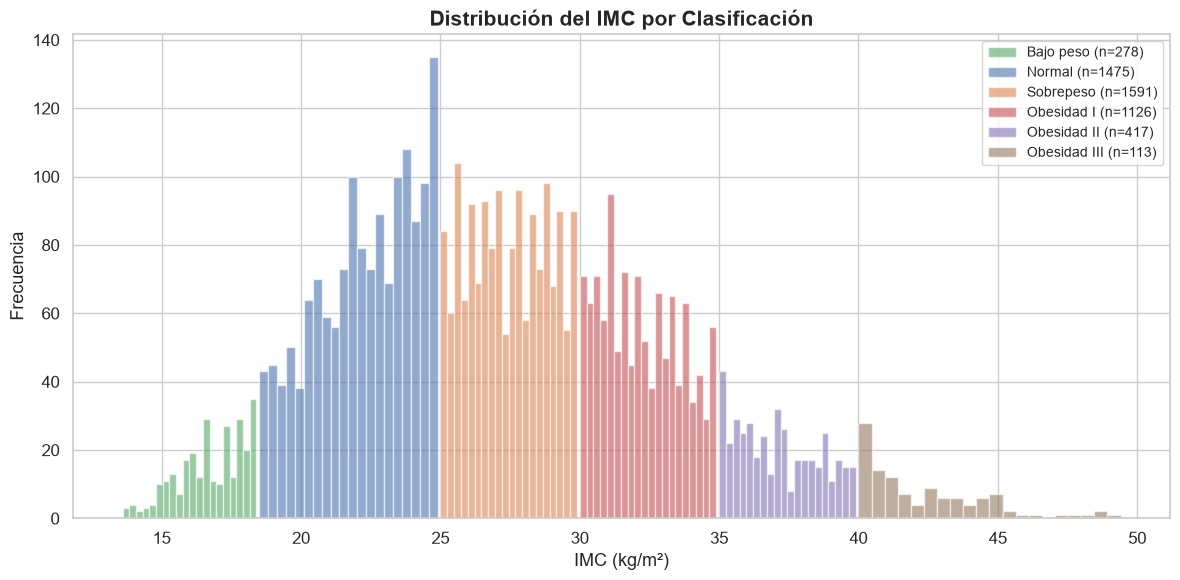

✅ Gráfica guardada en outputs/02_distribucion_imc.png


In [13]:
fig, ax = plt.subplots(figsize=(12, 6))

colores_imc = {'Bajo peso': '#55A868', 'Normal': '#4C72B0', 'Sobrepeso': '#DD8452', 
               'Obesidad I': '#C44E52', 'Obesidad II': '#8172B3', 'Obesidad III': '#937860'}
               
for cat in ['Bajo peso', 'Normal', 'Sobrepeso', 'Obesidad I', 'Obesidad II', 'Obesidad III']:
    subset = df[df['clasificacion_imc'] == cat]['imc']
    if len(subset) > 0:
        ax.hist(subset, bins=20, alpha=0.6, label=f"{cat} (n={len(subset)})", 
                color=colores_imc.get(cat, '#999999'), edgecolor='white')

ax.set_xlabel('IMC (kg/m²)', fontsize=13)
ax.set_ylabel('Frecuencia', fontsize=13)
ax.set_title('Distribución del IMC por Clasificación', fontsize=15, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/02_distribucion_imc.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica guardada en outputs/02_distribucion_imc.png")

### 12.3 Mapa de Calor Geográfico: Riesgo Cardiovascular en el Estado de Puebla

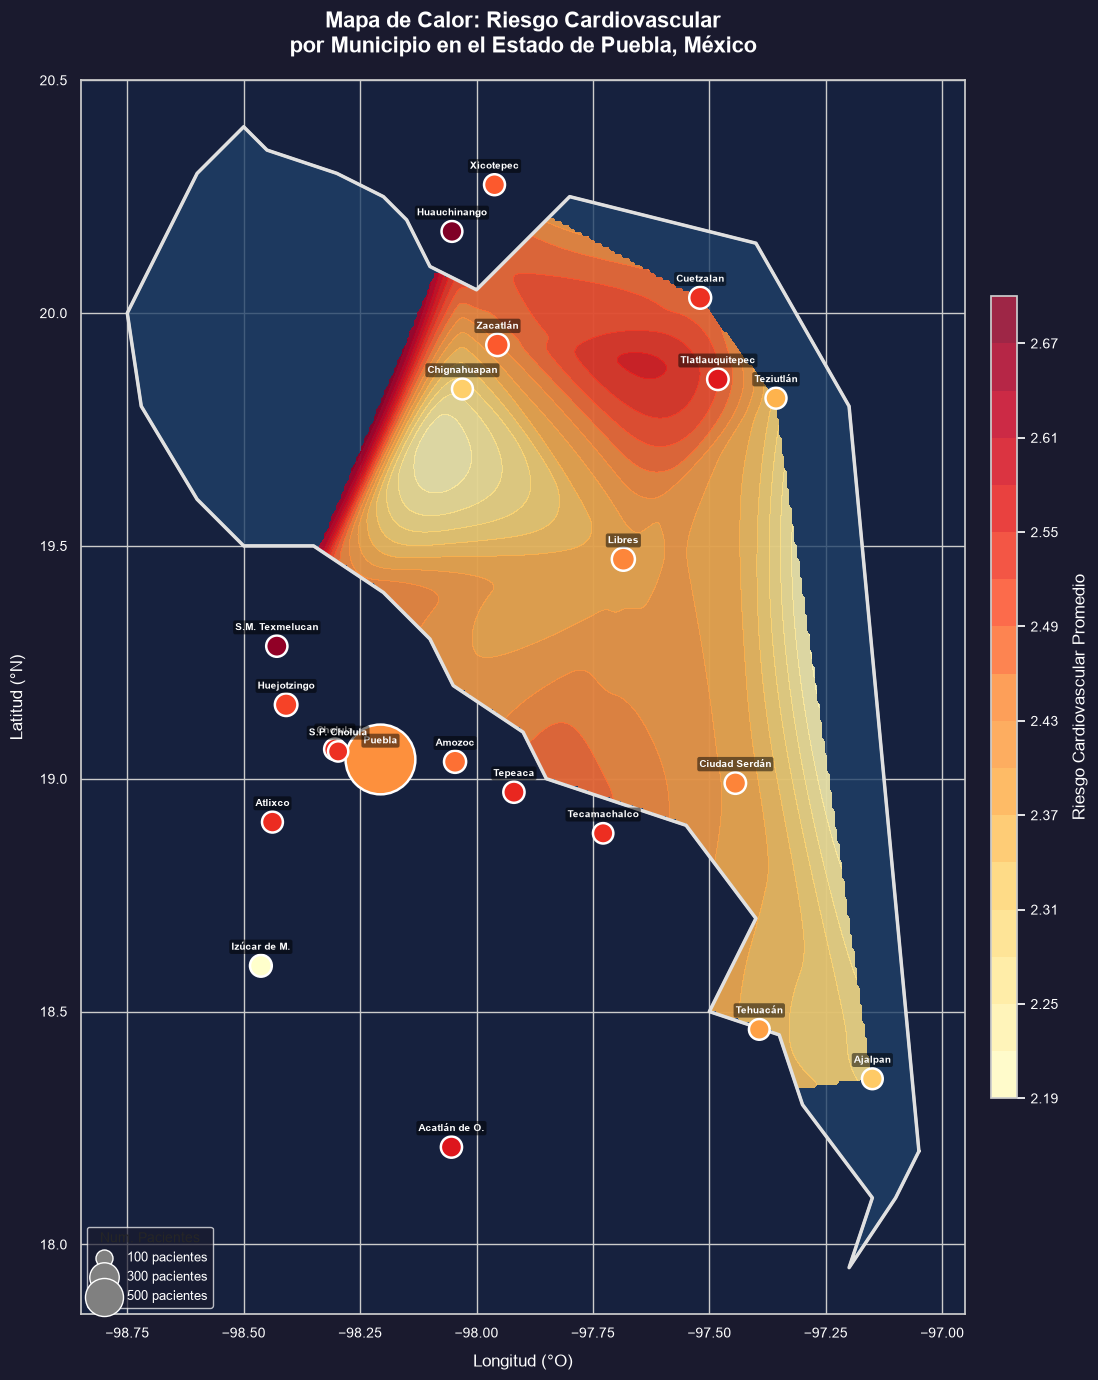

✅ Mapa geográfico de Puebla guardado en outputs/03_mapa_calor_puebla.png


In [14]:
from scipy.interpolate import griddata

# Coordenadas reales de los 22 municipios del estado de Puebla
municipios_coords = {
    'Puebla': (19.0414, -98.2063),
    'Tehuacán': (18.4617, -97.3928),
    'Atlixco': (18.9069, -98.4383),
    'Cholula': (19.0633, -98.3042),
    'San Pedro Cholula': (19.0586, -98.2972),
    'San Martín Texmelucan': (19.2847, -98.4289),
    'Huauchinango': (20.1753, -98.0528),
    'Teziutlán': (19.8172, -97.3569),
    'Izúcar de Matamoros': (18.5983, -98.4631),
    'Zacatlán': (19.9317, -97.9550),
    'Chignahuapan': (19.8369, -98.0303),
    'Amozoc': (19.0364, -98.0461),
    'Cuetzalan': (20.0328, -97.5197),
    'Xicotepec de Juárez': (20.2756, -97.9614),
    'Ajalpan': (18.3556, -97.1500),
    'Huejotzingo': (19.1589, -98.4089),
    'Libres': (19.4714, -97.6847),
    'Ciudad Serdán': (18.9906, -97.4442),
    'Tecamachalco': (18.8828, -97.7281),
    'Tepeaca': (18.9711, -97.9197),
    'Tlatlauquitepec': (19.8578, -97.4817),
    'Acatlán de Osorio': (18.2089, -98.0539),
}

# Calcular estadísticas por municipio
stats_mun = df.groupby('municipio').agg(
    n_pacientes=('id_paciente', 'count'),
    riesgo_medio=('riesgo_cardiovascular_score', 'mean')
).reset_index()

# Extraer coordenadas
lats = np.array([municipios_coords[m][0] for m in stats_mun['municipio']])
lons = np.array([municipios_coords[m][1] for m in stats_mun['municipio']])
riesgos = stats_mun['riesgo_medio'].values
pacientes = stats_mun['n_pacientes'].values

# Contorno aproximado del estado de Puebla (polígono simplificado)
puebla_outline_lon = [
    -97.05, -97.10, -97.20, -97.15, -97.30, -97.35, -97.50, -97.40, -97.55,
    -97.85, -97.90, -98.05, -98.10, -98.20, -98.35, -98.50, -98.60, -98.72,
    -98.75, -98.70, -98.65, -98.60, -98.55, -98.50, -98.45, -98.30, -98.20,
    -98.15, -98.10, -98.00, -97.90, -97.80, -97.60, -97.40, -97.20, -97.05
]
puebla_outline_lat = [
    18.20, 18.10, 17.95, 18.10, 18.30, 18.45, 18.50, 18.70, 18.90,
    19.00, 19.10, 19.20, 19.30, 19.40, 19.50, 19.50, 19.60, 19.80,
    20.00, 20.10, 20.20, 20.30, 20.35, 20.40, 20.35, 20.30, 20.25,
    20.20, 20.10, 20.05, 20.15, 20.25, 20.20, 20.15, 19.80, 18.20
]

# Crear grid de interpolación
margin = 0.15
grid_lon, grid_lat = np.meshgrid(
    np.linspace(min(lons) - margin, max(lons) + margin, 300),
    np.linspace(min(lats) - margin, max(lats) + margin, 300)
)

# Interpolar riesgo cardiovascular promedio en el grid
grid_riesgo = griddata(
    (lons, lats), riesgos,
    (grid_lon, grid_lat),
    method='cubic'
)

# --- Crear la figura ---
fig, ax = plt.subplots(figsize=(13, 14))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#16213e')

# Dibujar contorno del estado de Puebla
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection
puebla_poly = MplPolygon(
    list(zip(puebla_outline_lon, puebla_outline_lat)),
    closed=True, facecolor='#1f4068', edgecolor='#e0e0e0',
    linewidth=2.0, alpha=0.8, zorder=1
)
ax.add_patch(puebla_poly)

# Dibujar mapa de calor interpolado (solo dentro del contorno)
from matplotlib.path import Path
poly_path = Path(list(zip(puebla_outline_lon, puebla_outline_lat)))
points = np.column_stack([grid_lon.ravel(), grid_lat.ravel()])
mask = ~poly_path.contains_points(points).reshape(grid_lon.shape)
grid_riesgo_masked = np.ma.masked_where(mask | np.isnan(grid_riesgo), grid_riesgo)

contour = ax.contourf(grid_lon, grid_lat, grid_riesgo_masked, levels=15,
                       cmap='YlOrRd', alpha=0.85, zorder=2)

# Redibujar el borde del estado sobre el heatmap
ax.plot(puebla_outline_lon, puebla_outline_lat, color='#e0e0e0',
        linewidth=2.5, zorder=4, solid_capstyle='round')

# Dibujar puntos de municipios (tamaño proporcional a pacientes)
scatter = ax.scatter(lons, lats,
                     s=pacientes * 1.5,
                     c=riesgos, cmap='YlOrRd',
                     edgecolors='white', linewidths=1.8,
                     zorder=5, vmin=riesgos.min(), vmax=riesgos.max())

# Etiquetas de municipios
for _, row in stats_mun.iterrows():
    lat, lon = municipios_coords[row['municipio']]
    nombre = row['municipio']
    # Acortar nombres largos
    if nombre == 'San Martín Texmelucan':
        nombre = 'S.M. Texmelucan'
    elif nombre == 'Xicotepec de Juárez':
        nombre = 'Xicotepec'
    elif nombre == 'Izúcar de Matamoros':
        nombre = 'Izúcar de M.'
    elif nombre == 'Acatlán de Osorio':
        nombre = 'Acatlán de O.'
    elif nombre == 'San Pedro Cholula':
        nombre = 'S.P. Cholula'

    ax.annotate(nombre, (lon, lat),
                fontsize=7.5, color='white', fontweight='bold',
                ha='center', va='bottom',
                xytext=(0, 10), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.5, edgecolor='none'),
                zorder=6)

# Colorbar
cbar = plt.colorbar(contour, ax=ax, shrink=0.65, pad=0.02, aspect=30)
cbar.set_label('Riesgo Cardiovascular Promedio', fontsize=12, color='white', labelpad=10)
cbar.ax.tick_params(colors='white', labelsize=10)

# Títulos y etiquetas
ax.set_title('Mapa de Calor: Riesgo Cardiovascular\npor Municipio en el Estado de Puebla, México',
             fontsize=16, fontweight='bold', color='white', pad=20)
ax.set_xlabel('Longitud (°O)', fontsize=12, color='white', labelpad=10)
ax.set_ylabel('Latitud (°N)', fontsize=12, color='white', labelpad=10)
ax.tick_params(colors='white', labelsize=10)

# Ajustar límites al contorno de Puebla
ax.set_xlim(min(puebla_outline_lon) - 0.1, max(puebla_outline_lon) + 0.1)
ax.set_ylim(min(puebla_outline_lat) - 0.1, max(puebla_outline_lat) + 0.1)
ax.set_aspect('equal')

# Leyenda de tamaño de burbujas
for size, label in [(100, '100'), (300, '300'), (500, '500')]:
    ax.scatter([], [], s=size*1.5, c='gray', edgecolors='white',
               linewidths=1, label=f'{label} pacientes')
ax.legend(loc='lower left', fontsize=9, framealpha=0.7, 
          facecolor='#1a1a2e', edgecolor='white', labelcolor='white',
          title='Num. Pacientes', title_fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/03_mapa_calor_puebla.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("✅ Mapa geográfico de Puebla guardado en outputs/03_mapa_calor_puebla.png")

### 12.4 Diagrama de Dispersión: Presión Sistólica vs Colesterol Total

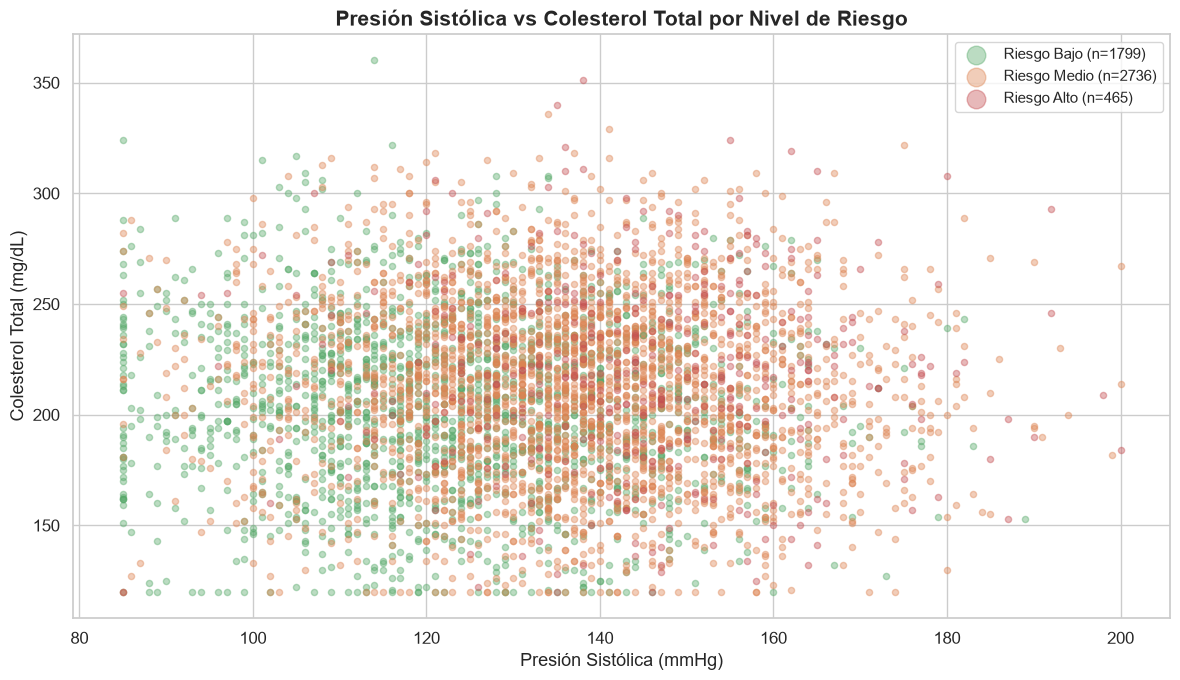

✅ Gráfica guardada en outputs/04_dispersion_presion_colesterol.png


In [15]:
fig, ax = plt.subplots(figsize=(12, 7))

colores_riesgo = {'Bajo': '#55A868', 'Medio': '#DD8452', 'Alto': '#C44E52'}
for riesgo in ['Bajo', 'Medio', 'Alto']:
    subset = df[df['riesgo_cardiovascular'] == riesgo]
    ax.scatter(subset['presion_sistolica'], subset['colesterol_total_mg_dl'], 
               alpha=0.4, s=20, label=f"Riesgo {riesgo} (n={len(subset)})", 
               color=colores_riesgo[riesgo])

ax.set_xlabel('Presión Sistólica (mmHg)', fontsize=13)
ax.set_ylabel('Colesterol Total (mg/dL)', fontsize=13)
ax.set_title('Presión Sistólica vs Colesterol Total por Nivel de Riesgo', fontsize=15, fontweight='bold')
ax.legend(fontsize=11, markerscale=3)
plt.tight_layout()
plt.savefig('../outputs/04_dispersion_presion_colesterol.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica guardada en outputs/04_dispersion_presion_colesterol.png")

### 12.5 Boxplot de Variables Clínicas por Nivel de Riesgo Cardiovascular

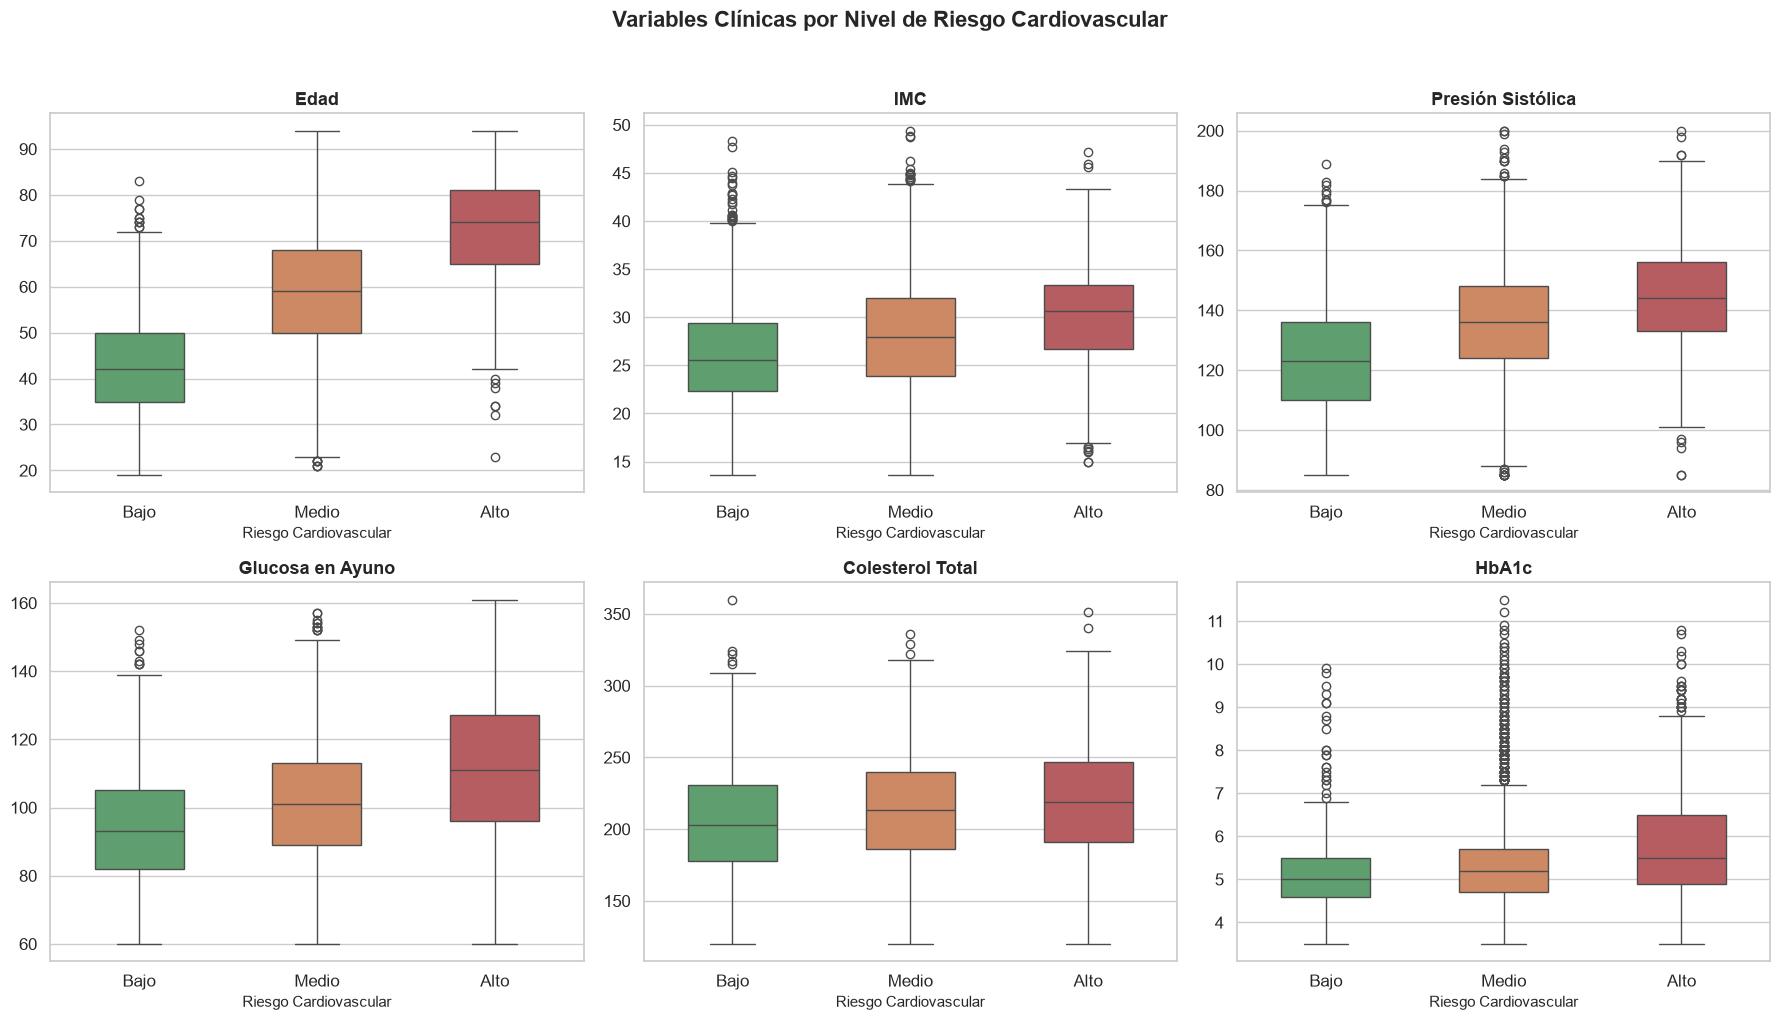

✅ Gráfica guardada en outputs/05_boxplot_variables_riesgo.png


In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
variables = ['edad', 'imc', 'presion_sistolica', 'glucosa_ayuno_mg_dl', 'colesterol_total_mg_dl', 'hba1c_pct']
titulos = ['Edad', 'IMC', 'Presión Sistólica', 'Glucosa en Ayuno', 'Colesterol Total', 'HbA1c']
orden_riesgo = ['Bajo', 'Medio', 'Alto']
paleta = {'Bajo': '#55A868', 'Medio': '#DD8452', 'Alto': '#C44E52'}

for ax, var, titulo in zip(axes.flatten(), variables, titulos):
    sns.boxplot(data=df, x='riesgo_cardiovascular', y=var, order=orden_riesgo,
                palette=paleta, ax=ax, width=0.5)
    ax.set_title(titulo, fontsize=13, fontweight='bold')
    ax.set_xlabel('Riesgo Cardiovascular', fontsize=11)
    ax.set_ylabel('')

fig.suptitle('Variables Clínicas por Nivel de Riesgo Cardiovascular', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/05_boxplot_variables_riesgo.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica guardada en outputs/05_boxplot_variables_riesgo.png")

### 12.6 Prevalencia de Comorbilidades en la Población

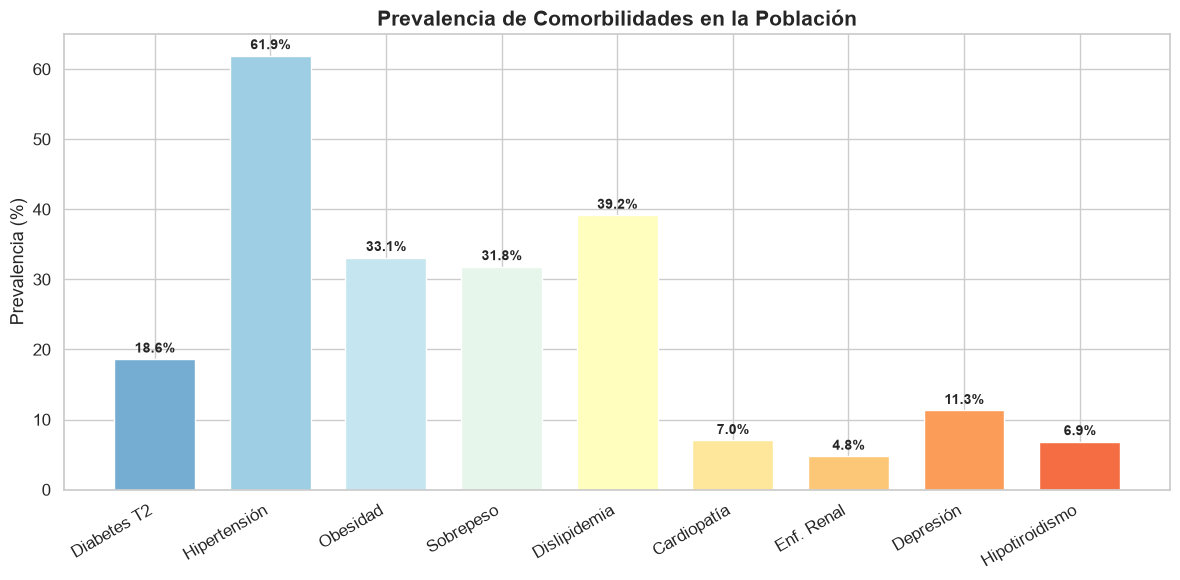

✅ Gráfica guardada en outputs/06_prevalencia_comorbilidades.png


In [17]:
comorbilidades = ['diabetes_mellitus_t2', 'hipertension_arterial', 'obesidad', 
                   'sobrepeso', 'dislipidemia', 'cardiopatia', 'enfermedad_renal', 
                   'depresion', 'hipotiroidismo']
nombres_display = ['Diabetes T2', 'Hipertensión', 'Obesidad', 'Sobrepeso', 
                   'Dislipidemia', 'Cardiopatía', 'Enf. Renal', 'Depresión', 'Hipotiroidismo']

prevalencias = [(df[c].sum() / len(df)) * 100 for c in comorbilidades]

fig, ax = plt.subplots(figsize=(12, 6))
colores = plt.cm.RdYlBu_r(np.linspace(0.2, 0.8, len(comorbilidades)))
bars = ax.bar(nombres_display, prevalencias, color=colores, edgecolor='white', width=0.7)

for bar, prev in zip(bars, prevalencias):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{prev:.1f}%", ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Prevalencia (%)', fontsize=13)
ax.set_title('Prevalencia de Comorbilidades en la Población', fontsize=15, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../outputs/06_prevalencia_comorbilidades.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica guardada en outputs/06_prevalencia_comorbilidades.png")

### 12.7 Mapa de Calor: Correlación entre Variables Clínicas

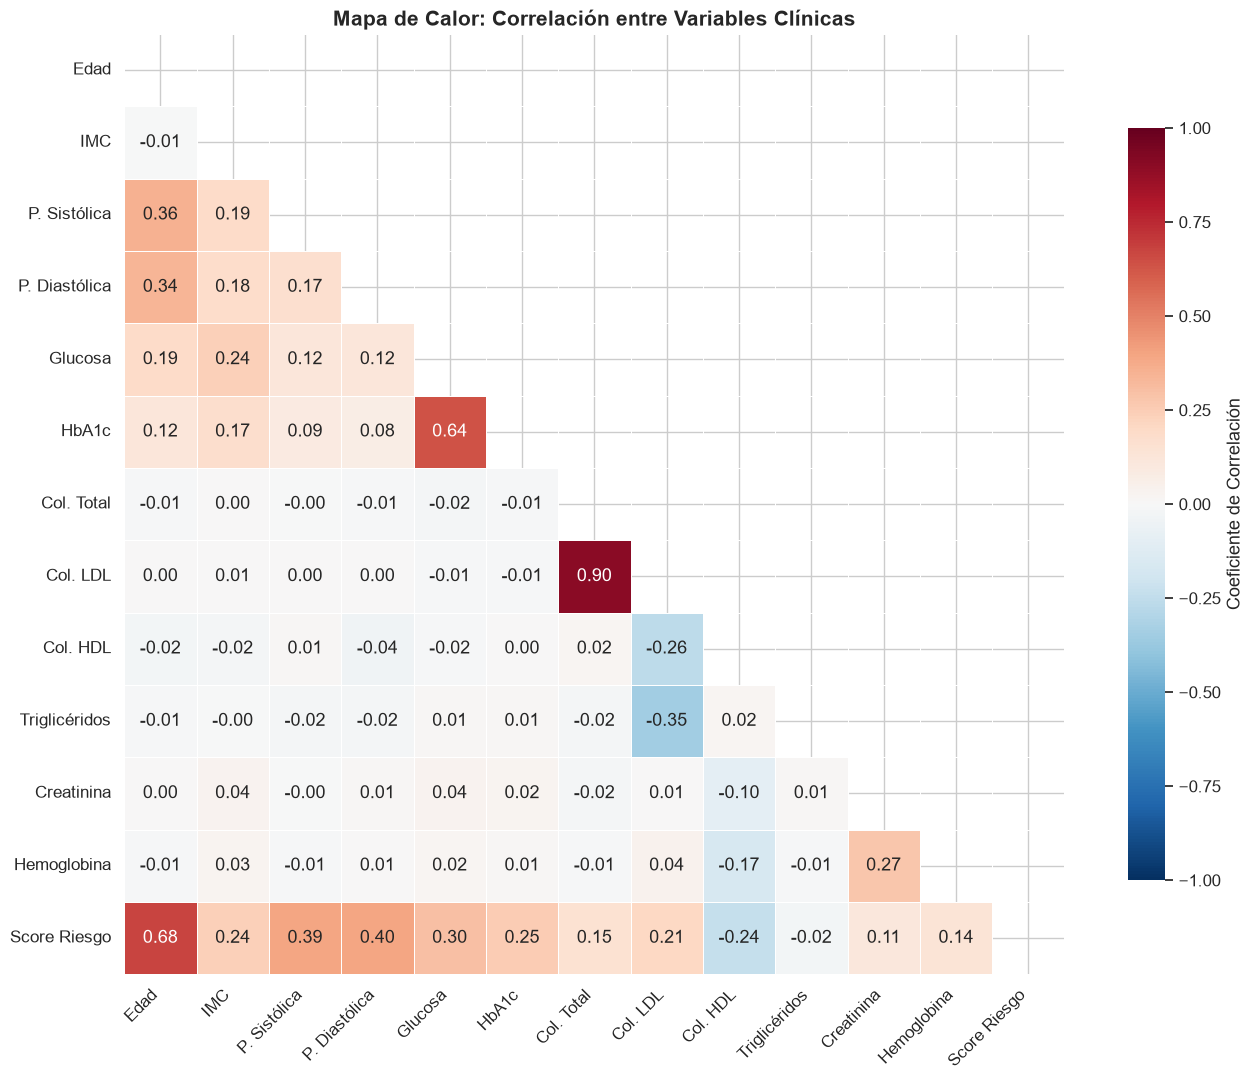

✅ Gráfica guardada en outputs/07_heatmap_correlacion_clinica.png


In [18]:
vars_correlacion = ['edad', 'imc', 'presion_sistolica', 'presion_diastolica',
                     'glucosa_ayuno_mg_dl', 'hba1c_pct', 'colesterol_total_mg_dl',
                     'colesterol_ldl_mg_dl', 'colesterol_hdl_mg_dl', 'trigliceridos_mg_dl',
                     'creatinina_mg_dl', 'hemoglobina_g_dl', 'riesgo_cardiovascular_score']

nombres_cortos = ['Edad', 'IMC', 'P. Sistólica', 'P. Diastólica', 'Glucosa', 'HbA1c',
                  'Col. Total', 'Col. LDL', 'Col. HDL', 'Triglicéridos', 
                  'Creatinina', 'Hemoglobina', 'Score Riesgo']

corr_matrix = df[vars_correlacion].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            xticklabels=nombres_cortos, yticklabels=nombres_cortos,
            cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de Correlación'},
            ax=ax)

ax.set_title('Mapa de Calor: Correlación entre Variables Clínicas', fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/07_heatmap_correlacion_clinica.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica guardada en outputs/07_heatmap_correlacion_clinica.png")

### 12.8 Mapa de Calor: Comorbilidades por Nivel de Riesgo Cardiovascular

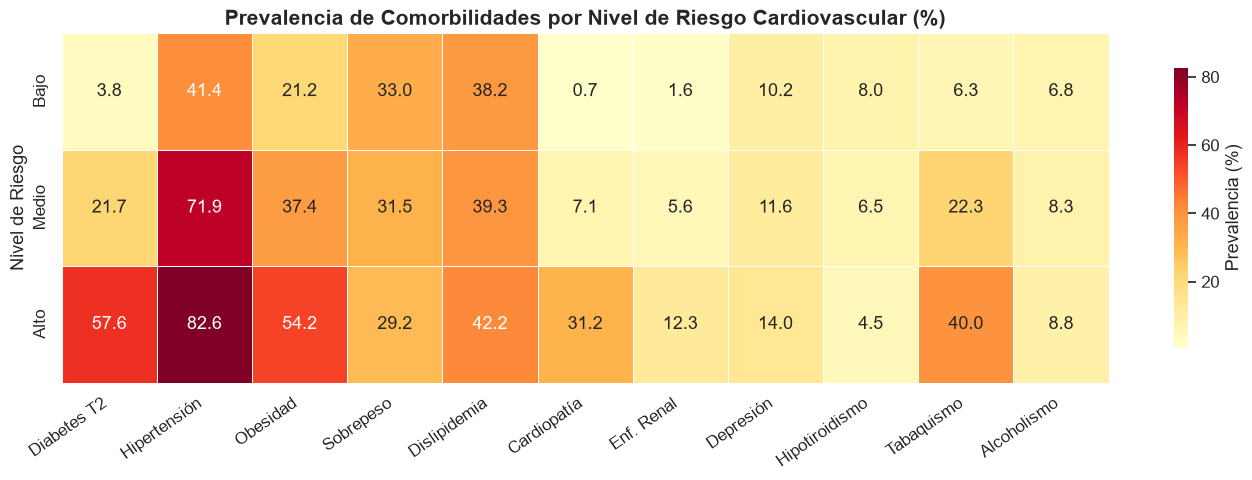

✅ Gráfica guardada en outputs/08_heatmap_comorbilidades_riesgo.png


In [19]:
comorbilidades = ['diabetes_mellitus_t2', 'hipertension_arterial', 'obesidad', 
                   'sobrepeso', 'dislipidemia', 'cardiopatia', 'enfermedad_renal', 
                   'depresion', 'hipotiroidismo', 'tabaquismo', 'alcoholismo']
nombres_comorb = ['Diabetes T2', 'Hipertensión', 'Obesidad', 'Sobrepeso', 
                  'Dislipidemia', 'Cardiopatía', 'Enf. Renal', 'Depresión', 
                  'Hipotiroidismo', 'Tabaquismo', 'Alcoholismo']

# Calcular prevalencia por nivel de riesgo
prev_por_riesgo = df.groupby('riesgo_cardiovascular')[comorbilidades].mean() * 100
prev_por_riesgo = prev_por_riesgo.loc[['Bajo', 'Medio', 'Alto']]
prev_por_riesgo.columns = nombres_comorb

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(prev_por_riesgo, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Prevalencia (%)', 'shrink': 0.8},
            ax=ax)

ax.set_title('Prevalencia de Comorbilidades por Nivel de Riesgo Cardiovascular (%)', 
             fontsize=15, fontweight='bold')
ax.set_ylabel('Nivel de Riesgo', fontsize=13)
ax.set_xlabel('')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('../outputs/08_heatmap_comorbilidades_riesgo.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica guardada en outputs/08_heatmap_comorbilidades_riesgo.png")

## 13. Análisis de la Distribución del Riesgo Cardiovascular (Punto 23)

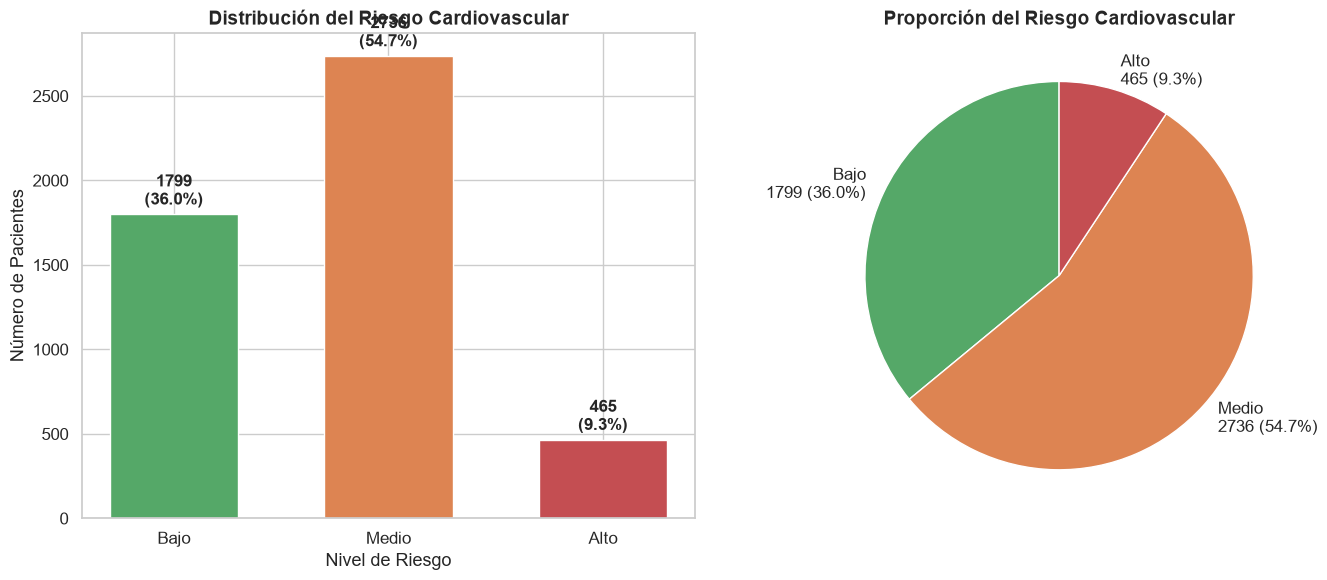


Distribución del Riesgo Cardiovascular:
  Bajo  :  1799 pacientes ( 36.0%)
  Medio :  2736 pacientes ( 54.7%)
  Alto  :   465 pacientes (  9.3%)
  Total :  5000 pacientes


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfica de barras
orden_riesgo = ['Bajo', 'Medio', 'Alto']
colores = ['#55A868', '#DD8452', '#C44E52']
conteo = df['riesgo_cardiovascular'].value_counts().reindex(orden_riesgo)

bars = axes[0].bar(conteo.index, conteo.values, color=colores, edgecolor='white', width=0.6)
for bar, valor in zip(bars, conteo.values):
    pct = (valor / len(df)) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f"{valor}\n({pct:.1f}%)", ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Nivel de Riesgo', fontsize=13)
axes[0].set_ylabel('Número de Pacientes', fontsize=13)
axes[0].set_title('Distribución del Riesgo Cardiovascular', fontsize=14, fontweight='bold')

# Gráfica de pastel
axes[1].pie(conteo.values, labels=[f"{r}\n{v} ({(v/len(df))*100:.1f}%)" for r, v in zip(conteo.index, conteo.values)],
            colors=colores, autopct='', startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Proporción del Riesgo Cardiovascular', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/09_distribucion_riesgo.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nDistribución del Riesgo Cardiovascular:")
print("=" * 50)
for riesgo in orden_riesgo:
    n = conteo[riesgo]
    pct = (n / len(df)) * 100
    print(f"  {riesgo:6s}: {n:5d} pacientes ({pct:5.1f}%)")
print(f"  {'Total':6s}: {len(df):5d} pacientes")

## 14. Resumen de Validación y Hallazgos

### Checklist de Validación

In [21]:
print("=" * 70)
print("RESUMEN DE VALIDACIÓN DEL DATASET")
print("=" * 70)
print()
print(f"  ✅ Dimensiones: {df.shape[0]} registros × {df.shape[1]} columnas")
print(f"  ✅ Nombres de columnas: formato snake_case, sin espacios")
print(f"  ✅ Tipos de datos: verificados y corregidos (fecha convertida)")
print(f"  ✅ Valores nulos: 0 encontrados")
print(f"  ✅ Registros duplicados: 0 encontrados")
print(f"  ✅ Rangos clínicos: validados (4 registros con IMC borderline)")
print(f"  ✅ Datos geográficos: 22 municipios reales de Puebla")
print(f"  ✅ Variable objetivo: riesgo_cardiovascular creada (Bajo/Medio/Alto)")
print(f"  ✅ Análisis estadístico: completado")
print(f"  ✅ Visualizaciones EDA: 9 gráficas generadas (incl. 3 mapas de calor, 1 geográfico)")
print()
print("El dataset cumple con todos los criterios de validación establecidos")
print("para la Práctica 05.")

RESUMEN DE VALIDACIÓN DEL DATASET

  ✅ Dimensiones: 5000 registros × 48 columnas
  ✅ Nombres de columnas: formato snake_case, sin espacios
  ✅ Tipos de datos: verificados y corregidos (fecha convertida)
  ✅ Valores nulos: 0 encontrados
  ✅ Registros duplicados: 0 encontrados
  ✅ Rangos clínicos: validados (4 registros con IMC borderline)
  ✅ Datos geográficos: 22 municipios reales de Puebla
  ✅ Variable objetivo: riesgo_cardiovascular creada (Bajo/Medio/Alto)
  ✅ Análisis estadístico: completado
  ✅ Visualizaciones EDA: 9 gráficas generadas (incl. 3 mapas de calor, 1 geográfico)

El dataset cumple con todos los criterios de validación establecidos
para la Práctica 05.
